In [ ]:
# import the fragment_C_Hole_Measurements.csv file and plot the data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=16"

import jax
import jax.numpy as jnp
key = jax.random.key(1234)

import corner
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS


numpyro.set_host_device_count(16)

print(jax.devices())


In [ ]:
# read the data from the csv file

data = pd.read_csv('../dataverse_files/1-Fragment_C_Hole_Measurements.csv')

In [ ]:
data

In [ ]:
data.describe()

In [ ]:
data.info()


In [ ]:
# plot points with x =Mean(X) and y = Mean(Y), number the points with their Hole and colour the points based on their section ID

plt.figure(figsize=(12, 8))  # Make the plot bigger
sns.set(style='ticks')

# Use a bright color palette
palette = sns.color_palette(palette='Dark2')

# Create the scatter plot
scatter_plot = sns.scatterplot(data=data, x='Mean(X)', y='Mean(Y)', hue='Section ID', palette=palette)

# Annotate each point with its hole number
for i in range(data.shape[0]):
    if i % 3 == 0:
        plt.annotate(
            data['Hole'].iloc[i], 
            (data['Mean(X)'].iloc[i], data['Mean(Y)'].iloc[i]), 
            textcoords="offset points", 
            xytext=(0, -30),  # Offset the label below the point
            ha='center', 
            arrowprops=dict(arrowstyle='-', color='black')
        )
# Set the y-axis to start from 50
plt.ylim(55, None)

# Force the x and y scales to be the same
plt.axis('equal')

# Add a title to the plot
plt.title('Scatter Plot of Mean(X) vs Mean(Y), with every 3rd Hole number and colours based on sections')

plt.show()



In [ ]:

# drop section ID and inter-hole distance columns
all_section_data = data.drop(columns='Inter-hole Distance')

all_section_data

# Build model for the hole locations

$$
\hat{m}_i = \hat{r}_{ij} + \hat{r}_{0j} \\
           = |r_{ij}| \cdot (\cos \Phi_{ij},\ \sin \Phi_{ij}) + \hat{r}_{0j} \\
           = |r_{ij}| \cdot (\cos (2 \pi \frac{i - 1}{N} + \alpha_j) ,\ \sin (2 \pi \frac{i - 1}{N} + \alpha_j)) + \hat{r}_{0j}
$$

## for the isotropic Cov matrix it suffices to have sigma**2 * indentity

## for the radial and tangential Cov matrix, in polar coordinates we have 

$$ Cov = [[\sigma_r^2,0], [0,\sigma_t^2]]  $$

$$Cov_{cartesian} = J \ Cov_{polar} \ J^T     $$

where 

$$ J = [[cos(\theta),-r*sin(\theta )],[sin(\theta),r *cos(\theta)]]$$

$$ Cov_{cartesian} = [[ \sigma_r^2cos^⁡2θ \ + \ \sigma_t^2r^2sin^⁡2θ, \ \ (\sigma_r^2−\sigma_t^2r^2)cos⁡θsin⁡θ],\ \ [    (\sigma_r^2 − \ \sigma_t^2r^2)\ cos⁡θsin⁡θ,  \ \ \sigma_r^2sin^⁡2θ \ + \ \sigma_t^2r^2cos^⁡2θ]]  $$

In [ ]:

# Filter out Section 0 and Section 4
filtered_data = all_section_data[~all_section_data['Section ID'].isin([0, 4])].copy()

# Reset row indices to be contiguous
filtered_data.reset_index(drop=True, inplace=True)


In [ ]:
filtered_data

In [ ]:
print(filtered_data.to_string())

In [60]:
# Define the predicted position function
def predicted_position(i, r, Phi_ij, x0j, y0j):
    
    m_x_i = r * jnp.cos(Phi_ij) + x0j
    m_y_i = r * jnp.sin(Phi_ij) + y0j
    return m_x_i, m_y_i

# Define the covariance function
def iso_cov(sigma, r, theta):
    cos_theta = jnp.cos(theta)
    sin_theta = jnp.sin(theta)
    cos_theta_sq = cos_theta ** 2
    sin_theta_sq = sin_theta ** 2
    cos_theta_sin_theta = cos_theta * sin_theta

    cov_11 = sigma**2 * cos_theta_sq + sigma**2 * r**2 * sin_theta_sq
    cov_12 = (sigma**2 - sigma**2 * r**2) * cos_theta_sin_theta
    cov_21 = cov_12
    cov_22 = sigma**2 * sin_theta_sq + sigma**2 * r**2 * cos_theta_sq

    
    # Stack into a batch of 2x2 covariance matrices
    return jnp.stack([
        jnp.stack([cov_11, cov_12], axis=-1),
        jnp.stack([cov_21, cov_22], axis=-1)
    ], axis=-2)  # Shape: (len(theta), 2, 2)


def phi_calc(i, N, alpha_j):
    phi = 2 * jnp.pi * (i - 1) / N + alpha_j
    return phi

# DEBUG = True
call_counter = 0

def model(x, y, section_id, hole_id):
    global call_counter
    call_counter += 1

    # Priors for shared parameters
    r = numpyro.sample('r', dist.Uniform(76.5, 78))
    N = numpyro.sample('N', dist.Uniform(351, 359))
    sigma = numpyro.sample('sigma', dist.Uniform(0.01, 0.05))  # Narrower prior

    # Priors for category-specific parameters (with narrower priors)
    x0j = numpyro.sample('x0j', dist.Normal(81, 1).expand([6]))  # Vectorized
    y0j = numpyro.sample('y0j', dist.Normal(135, 1).expand([6]))
    alpha_j = numpyro.sample('alpha_j', dist.Uniform(-2.5, -2).expand([6]))

    # Map section IDs to indices (e.g., {1 -> 0, ..., 7 -> 5})
    section_map = {s: i for i, s in enumerate(sorted(set(section_id)))}
    section_idx = jnp.array([section_map[s] for s in section_id])

    # Calculate phi for each hole
    phi = phi_calc(hole_id, N, alpha_j[section_idx])

    # Predicted positions (vectorized)
    m_x, m_y = predicted_position(hole_id, r, phi, x0j[section_idx], y0j[section_idx])

    # Covariance matrix as a function of phi
    Cov = iso_cov(sigma, r, phi) + jnp.eye(2) * 1e-6
    
    # if call_counter == (mcmc.num_samples + mcmc.num_warmup ) * mcmc.num_chains -1:

    #     print("Predicted Positions and Additional Data:")
    #     for i in range(len(filtered_data)):
    #         print(f"Row {i}: Hole ID={hole_id[i]},Section_idx={section_idx[i]}, m_x={m_x_np[i]:.4f}, m_y={m_y_np[i]:.4f}, x={x[i]:.4f}, y={y[i]:.4f}, phi={phi[i]:.4f}, x0j={x0j[section_idx[i]]}, y0j={y0j[section_idx[i]]}")  


    # Likelihood: Observed positions modeled as multivariate normal
    with numpyro.plate("data", len(x)):
        numpyro.sample(
            "obs",
            dist.MultivariateNormal(
                loc=jnp.stack([m_x, m_y], axis=-1),
                covariance_matrix=Cov,
            ),
            obs=jnp.stack([x, y], axis=-1),
        )



  0%|          | 0/52000 [00:00<?, ?it/s]

  0%|          | 0/52000 [00:00<?, ?it/s]

  0%|          | 0/52000 [00:00<?, ?it/s]

  0%|          | 0/52000 [00:00<?, ?it/s]

  0%|          | 0/52000 [00:00<?, ?it/s]

  0%|          | 0/52000 [00:00<?, ?it/s]

  0%|          | 0/52000 [00:00<?, ?it/s]

  0%|          | 0/52000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         N    358.78      0.22    358.84    358.49    359.00 495856.09      1.00
alpha_j[0]     -2.50      0.00     -2.50     -2.50     -2.50     49.14      1.00
alpha_j[1]     -2.50      0.00     -2.50     -2.50     -2.49    924.88      1.00
alpha_j[2]     -2.50      0.00     -2.50     -2.50     -2.50     35.13      1.00
alpha_j[3]     -2.50      0.01     -2.49     -2.50     -2.48 478457.96      1.00
alpha_j[4]     -2.49      0.01     -2.49     -2.50     -2.47 432939.24      1.00
alpha_j[5]     -2.50      0.00     -2.50     -2.50     -2.49   1992.21      1.00
         r     77.12      0.26     77.12     76.69     77.54  79163.73      1.00
     sigma      0.04      0.00      0.04      0.03      0.04 317377.01      1.00
    x0j[0]     79.84      0.28     79.62     79.33     79.92  84769.37      1.00
    x0j[1]     79.87      0.29     79.72     79.31     80.12 220723.21      1.00
    x0j[2]     79.98      0

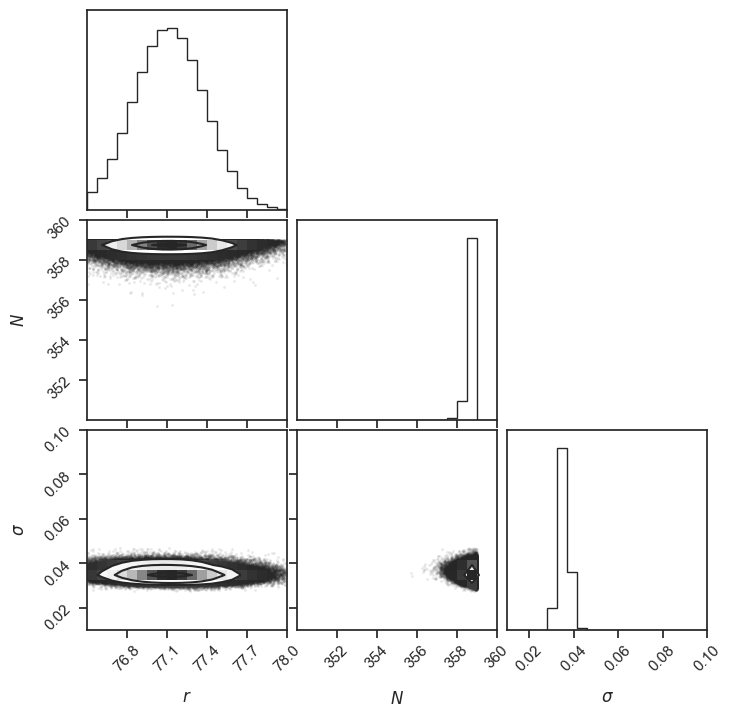

In [61]:

from numpyro.diagnostics import print_summary
from numpyro.infer.initialization import init_to_median





# Extract filtered data for use in the model
x = filtered_data['Mean(X)'].values
y = filtered_data['Mean(Y)'].values
section_id = filtered_data['Section ID'].values  # Updated section IDs
hole_id = filtered_data['Hole'].values

# Render the model
#numpyro.render_model(model, model_args=(x, y, section_id, hole_id))


# Run MCMC
nuts_kernel = NUTS(model, init_strategy=init_to_median)
mcmc = MCMC(nuts_kernel, num_warmup=2000, num_samples=50000, num_chains=8)
mcmc.run(jax.random.PRNGKey(0), x, y, section_id=section_id, hole_id=hole_id)

# Print quick summary
mcmc.print_summary()

samples = mcmc.get_samples()


# Plot the samples using corner
corner.corner(np.array(jnp.vstack((samples['r'], 
                                   samples['N'],
                                #    samples['x0j'],
                                #    samples['y0j'],
                                #    samples['alpha_j'],
                                   samples['sigma'])).T),
              labels=[r'$r$', r'$N$',  r'$\sigma$'],
              range=[(76.5, 78), (350, 360), (0.01, 0.1)]                     
            #   labels=[r'$r$', r'$N$', r'$x0j$', r'$y0j$', r'$\alpha_j$', r'$\sigma$'],
            #   range=[(76.5, 78), (350, 360), (77, 83), (132, 138), (-2.3, -1.7), (0.005, 0.05)]
              )
plt.show()

